In [71]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import os
from datetime import datetime

Ouverture du fichier pour la corespondance des noms de colonne

In [109]:
columns_identifier = pd.read_csv('data/columns_identifier.csv', sep=';', encoding="latin1")

columns_identifier["parameter_description_fr"] = columns_identifier["parameter_description_fr"].replace(to_replace=r';', value='/', regex=True)

dict_nameColumns = dict(zip(columns_identifier["parameter_shortname"], columns_identifier["parameter_description_fr"]))

columns_identifier.head()

,parameter_shortname,parameter_description_de,parameter_description_fr,parameter_description_it,parameter_description_en,parameter_group_de,parameter_group_fr,parameter_group_it,parameter_group_en,parameter_granularity,parameter_decimals,parameter_datatype,parameter_unit
0,dkl010d0,Windrichtung; Tagesmittel,Direction du vent/ moyenne journalière,Direzione del vento; media giornaliera,Wind direction; daily mean,Wind,vent,vento,wind,D,0,Integer,°
1,dkl010h0,Windrichtung; Stundenmittel,Direction du vent/ moyenne horaire,Direzione del vento; media oraria,Wind direction; hourly mean,Wind,vent,vento,wind,H,0,Integer,°
2,dkl010z0,Windrichtung; Zehnminutenmittel,Direction du vent/ moyenne sur 10 minutes,Direzione del vento; media su 10',Wind direction; ten minutes mean,Wind,vent,vento,wind,T,0,Integer,°
3,erefaod0,Referenzverdunstung nach FAO; Tagessumme,Évaporation de réference de FAO/ somme journal...,Evaporazione referenze di FAO; somma giornaliera,Reference evaporation from FAO; daily total,Verdunstung,évaporation,evaporazione,evaporation,D,1,Float,mm/d
4,erefaoh0,Referenzverdunstung nach FAO; Stundensumme,Évaporation de réference de FAO/ somme horaire,Evaporazione referenze di FAO; somma oraria,Reference evaporation from FAO; hourly total,Verdunstung,évaporation,evaporazione,evaporation,H,3,Float,mm/h


Ouverture du fichier d'itentification des stations

In [73]:
station_identifier = pd.read_csv('data/station_identifier.csv', sep=';', encoding="latin1")

dict_nameContry = dict(zip(station_identifier["station_abbr"], station_identifier["station_name"]))

station_identifier.head()

,station_abbr,station_name,station_canton,station_wigos_id,station_type_de,station_type_fr,station_type_it,station_type_en,station_dataowner,station_data_since,...,station_coordinates_wgs84_lat,station_coordinates_wgs84_lon,station_exposition_de,station_exposition_fr,station_exposition_it,station_exposition_en,station_url_de,station_url_fr,station_url_it,station_url_en
0,ABO,Adelboden,BE,0-20000-0-06735,Automatische Wetterstationen,Stations météorologiques automatiques,Stazioni meteorologiche automatiche,Automatic weather stations,"MeteoSchweiz, SLF",01.01.1901,...,46.491703,7.560703,Südosthang,Versant sud-est,Versante sud-orientale,south-eastern oriented slope,https://www.meteoschweiz.admin.ch/service-und-...,https://www.meteosuisse.admin.ch/services-et-p...,https://www.meteosvizzera.admin.ch/servizi-e-p...,https://www.meteoswiss.admin.ch/services-and-p...
1,AEG,Oberägeri,ZG,0-20000-0-06676,Automatische Wetterstationen,Stations météorologiques automatiques,Stazioni meteorologiche automatiche,Automatic weather stations,MeteoSchweiz,01.02.1993,...,47.133636,8.608206,Ebene,Plaine,Pianura,plain,https://www.meteoschweiz.admin.ch/service-und-...,https://www.meteosuisse.admin.ch/services-et-p...,https://www.meteosvizzera.admin.ch/servizi-e-p...,https://www.meteoswiss.admin.ch/services-and-p...
2,AIG,Aigle,VD,0-20000-0-06712,Automatische Wetterstationen,Stations météorologiques automatiques,Stazioni meteorologiche automatiche,Automatic weather stations,MeteoSchweiz,01.01.1961,...,46.326647,6.924472,Ebene,Plaine,Pianura,plain,https://www.meteoschweiz.admin.ch/service-und-...,https://www.meteosuisse.admin.ch/services-et-p...,https://www.meteosvizzera.admin.ch/servizi-e-p...,https://www.meteoswiss.admin.ch/services-and-p...
3,ALT,Altdorf,UR,0-20000-0-06672,Automatische Wetterstationen,Stations météorologiques automatiques,Stazioni meteorologiche automatiche,Automatic weather stations,MeteoSchweiz,01.01.1864,...,46.887069,8.621894,Ebene,Plaine,Pianura,plain,https://www.meteoschweiz.admin.ch/service-und-...,https://www.meteosuisse.admin.ch/services-et-p...,https://www.meteosvizzera.admin.ch/servizi-e-p...,https://www.meteoswiss.admin.ch/services-and-p...
4,AND,Andeer,GR,0-20000-0-06787,Automatische Wetterstationen,Stations météorologiques automatiques,Stazioni meteorologiche automatiche,Automatic weather stations,MeteoSchweiz,01.01.1901,...,46.610139,9.431981,Ebene,Plaine,Pianura,plain,https://www.meteoschweiz.admin.ch/service-und-...,https://www.meteosuisse.admin.ch/services-et-p...,https://www.meteosvizzera.admin.ch/servizi-e-p...,https://www.meteoswiss.admin.ch/services-and-p...


Function assemble les données et les enregistre

In [74]:

df_list = []
current_directory = os.getcwd()

OUTPUT_CSV = "\\data\\dataWeather.csv"

folder_path = current_directory + "\\data\\dataTemp\\month"
csv_files = os.listdir(folder_path)

for file in csv_files:
    try:
        file_path = folder_path + '\\' + file
        # Get the file size in kbytes
        file_size = os.path.getsize(file_path) / 1024

        if file_size > 1000:
            df = pd.read_csv(folder_path + '\\' + file)
            df_list.append(df)

    except Exception as e:
        print(f"⚠️ Erreur de lecture {file} : {e}")

# Concaténation avec gestion des colonnes manquantes
if df_list:
    df_final = pd.concat(df_list, ignore_index=True, sort=False)
    df_final.to_csv(current_directory + OUTPUT_CSV, index=False)
    print(f"✅ Fichier final enregistré sous {OUTPUT_CSV}")

✅ Fichier final enregistré sous \data\dataWeather.csv


Ouvre le fichier de donnée sur les satations

In [88]:
dataWeather =  pd.read_csv('data/dataWeather.csv', sep=';')

print(f"Dimension des données: {dataWeather.shape}")


Dimension des données: (4645786, 37)


Change le format de la date et ajoute une cologne mois et année

In [89]:
dataWeather['reference_timestamp'] = pd.to_datetime(dataWeather['reference_timestamp'], format='%d.%m.%Y %H:%M')
dataWeather['year'] = dataWeather['reference_timestamp'].dt.year
dataWeather['month'] = dataWeather['reference_timestamp'].dt.month

Supprime les lignes en dessous de 1960

In [90]:
year_selected = 1960

dataWeather = dataWeather[dataWeather['reference_timestamp'].dt.year >= year_selected]

Ajout une cologne altitude, longitude et latitude

In [ ]:
dataWeather = dataWeather.merge(
    station_identifier[['station_abbr', 'station_height_masl']], 
    on='station_abbr', 
    how='left'  # ou 'inner' si tu veux ignorer les stations non communes
)

dataWeather = dataWeather.merge(
    station_identifier[['station_abbr', 'station_coordinates_lv95_east']], 
    on='station_abbr', 
    how='left'  # ou 'inner' si tu veux ignorer les stations non communes
)

dataWeather = dataWeather.merge(
    station_identifier[['station_abbr', 'station_coordinates_lv95_north']], 
    on='station_abbr', 
    how='left'  # ou 'inner' si tu veux ignorer les stations non communes
)

dataWeather.head()

,station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,...,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,year,month,station_height_masl,station_coordinates_lv95_east,station_coordinates_lv95_north
0,ABO,1960-01-01,2.2,NaN,NaN,NaN,NaN,NaN,54.7,4.1,...,NaN,NaN,NaN,NaN,NaN,1960,1,1321.0,2609372.0,1148939.0
1,ABO,1960-01-02,1.5,NaN,NaN,NaN,NaN,NaN,88.3,5.8,...,NaN,NaN,NaN,NaN,NaN,1960,1,1321.0,2609372.0,1148939.0
2,ABO,1960-01-03,3.1,NaN,NaN,NaN,NaN,NaN,91.0,6.9,...,NaN,NaN,NaN,NaN,NaN,1960,1,1321.0,2609372.0,1148939.0
3,ABO,1960-01-04,0.1,NaN,NaN,NaN,NaN,NaN,79.7,5.1,...,NaN,NaN,NaN,NaN,NaN,1960,1,1321.0,2609372.0,1148939.0
4,ABO,1960-01-05,2.3,NaN,NaN,NaN,NaN,NaN,50.7,3.6,...,NaN,NaN,NaN,NaN,NaN,1960,1,1321.0,2609372.0,1148939.0


Modifie le nom des colonnes et le nom des villes

In [94]:
dataWeather_name = dataWeather.copy()


dataWeather_name['station_abbr'] = dataWeather['station_abbr'].map(dict_nameContry)

dataWeather_name.rename(dict_nameColumns, axis=1, inplace=True)

Information sur la base de donnée

In [ ]:
dataWeather_name.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2911899 entries, 0 to 2911898
Data columns (total 42 columns):
 #   Column                                                                                Dtype         
---  ------                                                                                -----         
 0   station_abbr                                                                          object        
 1   reference_timestamp                                                                   datetime64[ns]
 2   Température de l'air à 2 m du sol/ moyenne journalière                                float64       
 3   Température de l'air à 2 m du sol/ maximum journalier                                 float64       
 4   Température de l'air à 2 m du sol/ minimum journalier                                 float64       
 5   Température de l'air à 5 cm de l'herbe/ moyenne journalière                           float64       
 6   Température de l'air à 5 cm de l'h

In [182]:
dataWeather_name.head()

,station_abbr,reference_timestamp,Température de l'air à 2 m du sol/ moyenne journalière,Température de l'air à 2 m du sol/ maximum journalier,Température de l'air à 2 m du sol/ minimum journalier,Température de l'air à 5 cm de l'herbe/ moyenne journalière,Température de l'air à 5 cm de l'herbe/ maximum journalier,Température de l'air à 5 cm de l'herbe/ minimum journalier,Humidité de l'air relative à 2 m du sol/ moyenne journalière,Pression de vapeur à 2 m du sol/ moyenne journalière,...,Évaporation de réference de FAO/ somme journalière,Jours de refroidissment (CDD),Direction du vent/ moyenne journalière,Degrés jours (HGT12/20),Degrés jours (ATD12/12),year,month,station_height_masl,station_coordinates_lv95_east,station_coordinates_lv95_north
0,Adelboden,1960-01-01,2.2,NaN,NaN,NaN,NaN,NaN,54.7,4.1,...,NaN,NaN,NaN,NaN,NaN,1960,1,1321.0,2609372.0,1148939.0
1,Adelboden,1960-01-02,1.5,NaN,NaN,NaN,NaN,NaN,88.3,5.8,...,NaN,NaN,NaN,NaN,NaN,1960,1,1321.0,2609372.0,1148939.0
2,Adelboden,1960-01-03,3.1,NaN,NaN,NaN,NaN,NaN,91.0,6.9,...,NaN,NaN,NaN,NaN,NaN,1960,1,1321.0,2609372.0,1148939.0
3,Adelboden,1960-01-04,0.1,NaN,NaN,NaN,NaN,NaN,79.7,5.1,...,NaN,NaN,NaN,NaN,NaN,1960,1,1321.0,2609372.0,1148939.0
4,Adelboden,1960-01-05,2.3,NaN,NaN,NaN,NaN,NaN,50.7,3.6,...,NaN,NaN,NaN,NaN,NaN,1960,1,1321.0,2609372.0,1148939.0


Nombre de donnée manquante dans la base

In [96]:
dataWeather_name.isnull().sum(axis=0)

station_abbr                                                                                  0
reference_timestamp                                                                           0
Température de l'air à 2 m du sol/ moyenne journalière                                   640714
Température de l'air à 2 m du sol/ maximum journalier                                    770938
Température de l'air à 2 m du sol/ minimum journalier                                    706083
Température de l'air à 5 cm de l'herbe/ moyenne journalière                             1996433
Température de l'air à 5 cm de l'herbe/ maximum journalier                              1996413
Température de l'air à 5 cm de l'herbe/ minimum journalier                              1959702
Humidité de l'air relative à 2 m du sol/ moyenne journalière                             720684
Pression de vapeur à 2 m du sol/ moyenne journalière                                     732318
Pression atmosphérique à l'altitude du b

Calcul de la moyenne, de l’écart-type (standard deviation) et le nombre d’observations (count) par groupe et par mois

In [183]:
id_temp = columns_identifier.loc[columns_identifier['parameter_description_fr'] == "Température de l'air à 2 m du sol/ moyenne journalière", 'parameter_shortname']

id_temp = str(id_temp)
id_temp = id_temp.split('\n')
id_temp = id_temp[0].split(' ')
id_temp = id_temp[len(id_temp)-1]

dw_hw = dataWeather.groupby(['year', 'month', 'station_height_masl'])[id_temp].agg(
    mean='mean',
    std='std',
    count='count'
).reset_index()


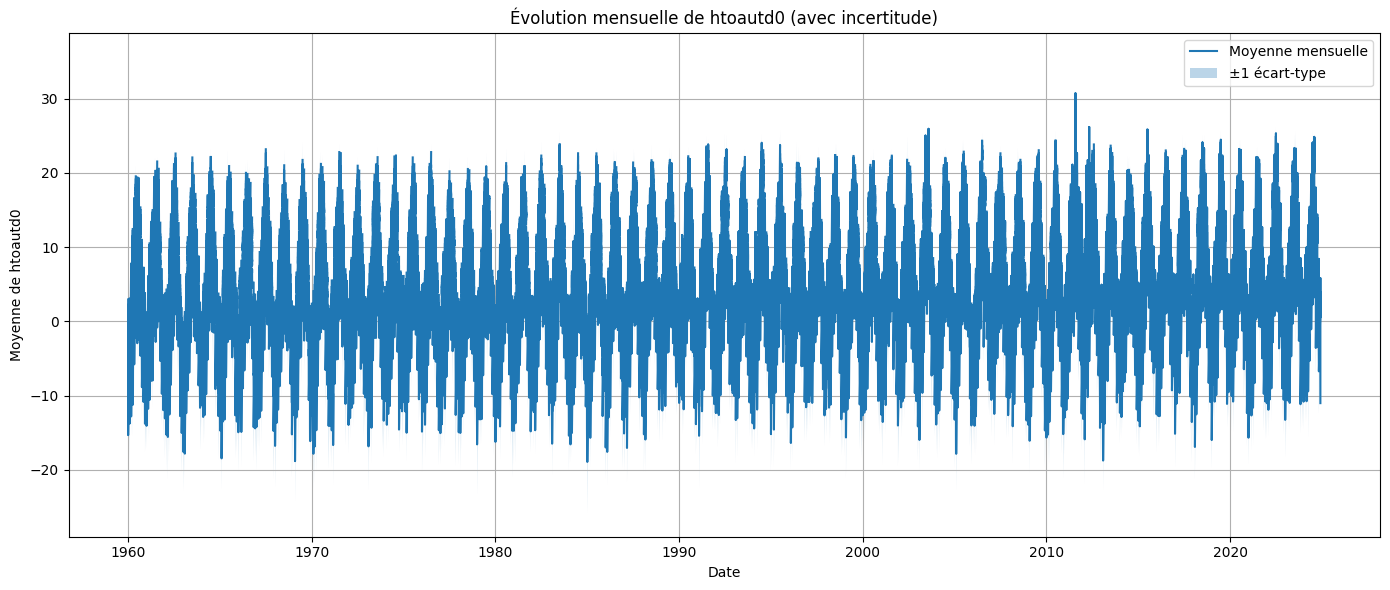

In [184]:
# Graphique par année-mois combinés
dw_hw['date'] = pd.to_datetime(dw_hw[['year', 'month']].assign(day=1))

plt.figure(figsize=(14, 6))
plt.plot(dw_hw['date'], dw_hw['mean'], label='Moyenne mensuelle')
plt.fill_between(dw_hw['date'],
                 dw_hw['mean'] - dw_hw['std'],
                 dw_hw['mean'] + dw_hw['std'],
                 alpha=0.3, label='±1 écart-type')
plt.title("Évolution mensuelle de htoautd0 (avec incertitude)")
plt.xlabel("Date")
plt.ylabel("Moyenne de htoautd0")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Information sur la base de donnée 2000 mètres à 2500 mètres

In [ ]:
dataWeather_2000_2500_name.info()
dataWeather_2000_2500_name.head()

Nombre de donnée manquante dans la base

In [ ]:
dataWeather_2000_2500_name.isnull().sum(axis=0)

Information sur la base de donnée 2500 mètres à 3000 mètres

In [ ]:
dataWeather_2500_3000_name.info()
dataWeather_2500_3000_name.head()

Nombre de donnée manquante dans la base

In [ ]:
dataWeather_2500_3000_name.isnull().sum(axis=0)

Information sur la base de donnée 3000 mètres à 3500 mètres

In [ ]:
dataWeather_3000_3500_name.info()
dataWeather_3000_3500_name.head()

Nombre de donnée manquante dans la base

In [ ]:
dataWeather_3000_3500_name.isnull().sum(axis=0)

Information sur la base de donnée 3500 mètres à 4000 mètres

In [ ]:
dataWeather_3500_4000_name.info()
dataWeather_3500_4000_name.head()

Nombre de donnée manquante dans la base

In [ ]:
dataWeather_3500_4000_name.isnull().sum(axis=0)